In [22]:
'''
Use EBHC and water correction to fit the simulation phantom to real data
'''

'\nUse EBHC and water correction to fit the simulation phantom to real data\n'

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.optimize
import SimpleITK as sitk

import pcct_md_diffusion.utils as utils
from pcct_md_diffusion.fbp import additional_fbp_filter
from pcct_md_diffusion.utils import load_nist_attenuation, load_mixture_attenuation_from_composition_file
from pcct_md_diffusion.locations import base_input_dir

In [24]:
# load material attenuation data
ich = 0  # channel to analyze
min_kev = 20
max_kev = 120
step_kev = 5
kevs = np.arange(min_kev, max_kev + 1, step_kev)

df_att, dict_density = load_mixture_attenuation_from_composition_file(
    os.path.join(base_input_dir, 'omnitom_pcd/calibration/material_composition.csv'),
    os.path.join(base_input_dir, 'spectrum/NIST'),
    kevs=kevs,
    return_density=True
)

df_water = load_nist_attenuation(
    os.path.join(base_input_dir, 'spectrum/NIST/water.txt'),
    kevs=kevs
)

df_att['true_water'] = df_water['mu']
dict_density['true_water'] = 1.0

In [25]:
att_cdte = utils.load_mixture_attenuation(
    os.path.join(base_input_dir, 'spectrum/NIST'),
    ['Cd', 'Te'],
    [112.414, 127.60],
    density=5.85,
    kevs=kevs
)

assumed_thickness = 1  # in mm
cdte_absorption = 1 - np.exp(-att_cdte['mu'].values * assumed_thickness)

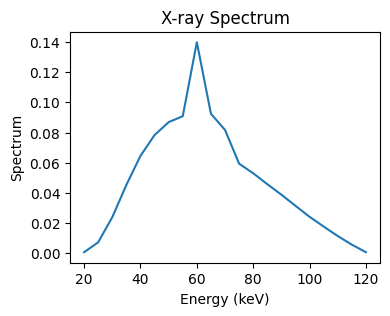

In [26]:
# load spectrum
# fist load with 1 kev step, then average to get the spectrum at the desired kevs

df_spec = pd.read_csv(os.path.join(base_input_dir, 'spectrum/xray/spektr_120kVp_Be2p0_Cu0p127_omnitom.csv'))

spectrum = [] 
for kev in kevs:
    idx = (df_spec['Energy_keV'] >= kev - (step_kev - 1) / 2) & (df_spec['Energy_keV'] <= kev + (step_kev - 1) / 2)
    spectrum.append(df_spec[idx]['Photons'].values.sum() / step_kev)
spectrum = np.array(spectrum)
spectrum = spectrum * cdte_absorption  # apply CdTe absorption
if ich == 0:
    pass
elif ich == 1:
    spectrum[kevs < 40] = 0
elif ich == 2:
    spectrum[kevs < 50] = 0

spectrum = spectrum / spectrum.sum()  # normalize

df_spec = pd.DataFrame({
    'energy': kevs,
    'spectrum': spectrum
})

plt.figure(figsize=(4, 3))
plt.plot(df_spec['energy'], df_spec['spectrum'])
plt.xlabel('Energy (keV)')
plt.ylabel('Spectrum')
plt.title('X-ray Spectrum')
plt.show()

Loading channel 0...
Loading channel 1...
Loading channel 2...


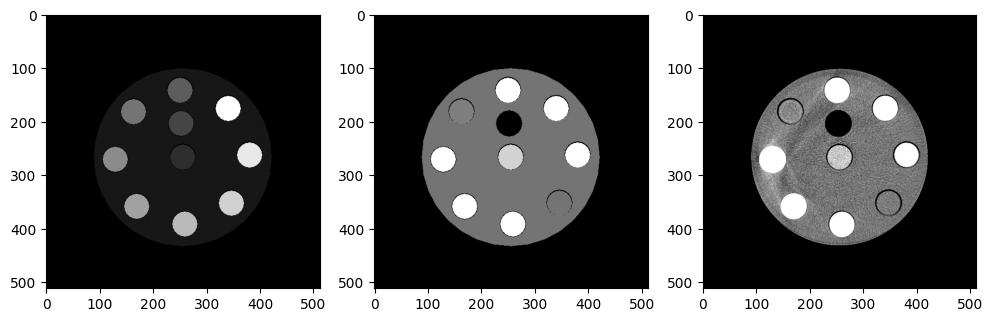

In [27]:
# load mask phantom
calibration_dir = os.path.join(base_input_dir, 'omnitom_pcd/calibration/calibration_8_41/img/1')
sitk_mask = sitk.ReadImage(os.path.join(calibration_dir, 'segmentation.seg.nrrd'))
dx, dy, dz = sitk_mask.GetSpacing()
mask = sitk.GetArrayFromImage(sitk_mask)[[0]]

# load phantom material labels
df_mask = pd.read_csv(os.path.join(calibration_dir, 'materials.csv'))

# compose a 60keV phantom
img_mono_60 = np.zeros_like(mask, dtype=np.float32)
for _, row in df_mask.iterrows():
    label = row['Seg']
    material = row['Material']
    mu = df_att[df_att['energy'] == 60][material].values[0]
    img_mono_60[mask == label] = mu

# water attenuation at 60keV
mu_water_60 = df_att[df_att['energy'] == 60]['true_water'].values[0]

# load real phantom
imgs, _, _, _ = utils.load_image(calibration_dir)
imgs = imgs[:, [0], ...]

mu_waters = mu_waters = np.array([0.0196, 0.0192, 0.0186])
display_vmins = (-50 + 1000) / 1000 * mu_waters
display_vmaxs = (50 + 1000) / 1000 * mu_waters

imgs[imgs < -1000] = -1000
imgs = (imgs + 1000) / 1000 * mu_waters[:, None, None, None]
imgs = imgs.astype(np.float32)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(mask[0], 'gray')

plt.subplot(1, 3, 2)
plt.imshow(img_mono_60[0], 'gray', vmin=mu_water_60-0.001, vmax=mu_water_60 + 0.001)

plt.subplot(1, 3, 3)
plt.imshow(imgs[ich, 0], 'gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.show()

In [51]:
df = get_roi_hu(imgs[ich], mask, df_mask, mu_waters[ich])
df

,label,material,roi_hu
0,1,water_base,-4.415217
1,2,brain,25.020753
2,3,adipose,-78.323456
3,4,iodine_10,279.747171
4,5,true_water,2.125803
5,6,calcium_300,1024.275992
6,7,calcium_100,319.785203
7,8,calcium_50,156.341893
8,9,water,-4.046395
9,10,iodine_2,54.950800


In [50]:
df

,label,material,roi_hu
0,1,water_base,-5.836435
1,2,brain,24.612967
2,3,adipose,-78.384373
3,4,iodine_10,278.538732
4,5,true_water,1.816946
5,6,calcium_300,1021.685965
6,7,calcium_100,318.719124
7,8,calcium_50,155.577638
8,9,water,-4.367036
9,10,iodine_2,54.491886


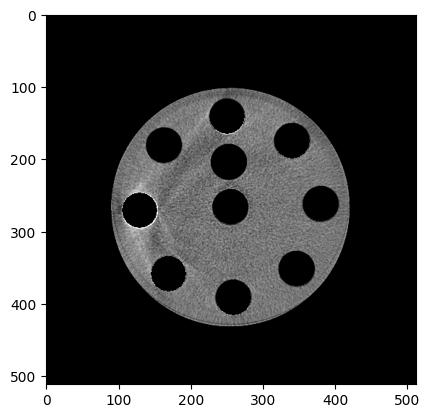

In [43]:
plt.imshow(imgs[ich, 0] * np.where(mask[0] == 1, 1, 0), 'gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])

In [46]:
np.sum(imgs[ich, 0] * np.where(mask[0] == 1, 1, 0)) / np.sum(np.where(mask[0] == 1, 1, 0)) / mu_waters[ich] * 1000 - 1000

np.float64(-4.415094169682675)

In [28]:
# geometry
geometry_path = os.path.join(base_input_dir, 'omnitom_pcd/geometry/omnitom_3x3_parallel_fov_308.cfg')
geo = utils.load_geometry(geometry_path)
geo.nx = imgs.shape[-1]
geo.ny = imgs.shape[-2]
geo.nz = imgs.shape[-3]
geo.nv = geo.nz
geo.dx = dx
geo.dy = dy
geo.dz = dz
geo.dv = dz
leapct = utils.set_leapct_geometry(geo)
leapct.print_parameters()


======== CT Parallel-Beam Geometry ========
number of angles: 1440
number of detector elements (rows, cols): 1 x 878
angular range: 360.000000 degrees
detector pixel size: 5.656000 mm x 0.351570 mm
center detector pixel: 0.000000, 445.750000

======== CT Volume ========
number of voxels (x, y, z): 512 x 512 x 1
voxel size: 0.601562 mm x 0.601562 mm x 5.656000 mm
FOV: [-154.000000, 154.000000] x [-154.000000, 154.000000] x [-2.828000, 2.828000]

======== Processing Settings ========
GPU processing on devices 0, 1
GPU with least amount of memory: 35.161964 GB



True

Forward projecting...
Channel 0
Channel 1
Channel 2
Reconstructing...
Channel 0
Channel 1
Channel 2


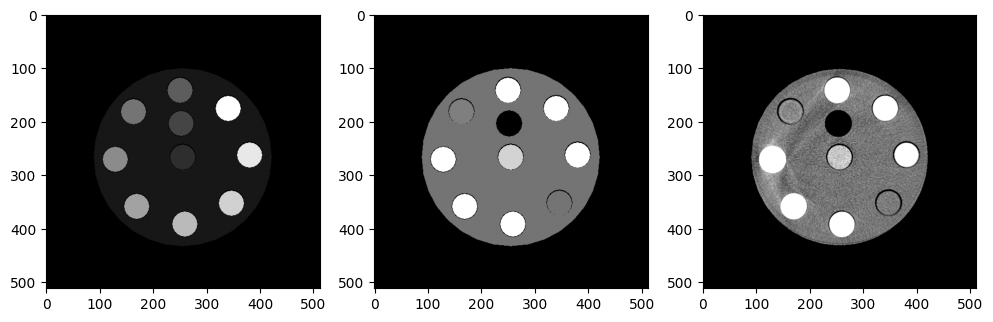

In [29]:
# cut off the area outside the phantom (foam) then do forward projection
phantom_mask = np.where(mask > 0, 1, 0)
# fill hole slice by slice
for i in range(phantom_mask.shape[0]):
    phantom_mask[i] = scipy.ndimage.binary_fill_holes(phantom_mask[i])

# set to air outside the phantom
imgs_masked = imgs.copy()
for ch in range(imgs.shape[0]):
    imgs_masked[ch] = np.where(phantom_mask > 0, imgs[ch], 0)

# forward projection
print('Forward projecting...', flush=True)
current_fp = leapct.allocate_projections()
prjs = []
for ch in range(imgs_masked.shape[0]):
    print('Channel', ch, flush=True)
    leapct.project(current_fp, imgs_masked[ch])
    prjs.append(np.copy(current_fp, 'C'))
prjs = np.array(prjs)

# reconstruction
print('Reconstructing...', flush=True)
fbps = []
for ch in range(prjs.shape[0]):
    print('Channel', ch, flush=True)
    current_fbp = leapct.FBP(prjs[ch])
    fbps.append(np.copy(current_fbp, 'C'))
fbps = np.array(fbps)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(mask[0], 'gray')

plt.subplot(1, 3, 2)
plt.imshow(img_mono_60[0], 'gray', vmin=mu_water_60-0.001, vmax=mu_water_60 + 0.001)

plt.subplot(1, 3, 3)
plt.imshow(fbps[ich, 0], 'gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.show()

In [30]:
# forward project each material and make the ploychromatic projection
current_fp = leapct.allocate_projections()
prjs_materials = []
for i in range(len(df_mask)):
    label = df_mask.loc[i, 'Seg']
    material = df_mask.loc[i, 'Material']
    img_material = np.where(mask == label, 1, 0).astype(np.float32)
    _ = leapct.project(current_fp, img_material)
    prjs_materials.append(current_fp.copy())
prjs_materials = np.array(prjs_materials)

# the attenuation coefficient of each material at each energy
mus_materials = []
for i in range(len(df_mask)):
    material = df_mask.loc[i, 'Material']
    mus_materials.append(df_att[material].values)
mus_materials = np.array(mus_materials)

# compute the polychromatic projection
attenuation = np.sum(prjs_materials[..., None] * mus_materials[:, None, None, None, :], axis=0)
prjs_poly_simul = -np.log(np.sum(spectrum * np.exp(-attenuation), axis=-1)).astype(np.float32)

In [31]:
def water_bhc_calibration_simul(att_water, spectrum, mu_water, max_thickness=300, poly_order=3):
    thicknesses = np.linspace(0, max_thickness, 100)
    attenuation = att_water * thicknesses[:, None]
    prjs = -np.log(np.sum(spectrum * np.exp(-attenuation), axis=-1))
    prjs[prjs < 0] = 0

    # use polynomial fit without intercept
    A = np.vstack([prjs**i for i in range(1, poly_order + 1)]).T
    b = mu_water * thicknesses
    coeffs = np.linalg.lstsq(A, b, rcond=None)[0]
    return coeffs


def apply_water_bhc(prjs, coeffs):
    return np.sum([coeffs[i] * prjs**(i + 1) for i in range(len(coeffs))], axis=0).astype(np.float32)

In [32]:
def get_roi_hu(img, mask, df_mask, mu_water):
    df_roi_hu = []
    for i, row in df_mask.iterrows():
        label = row['Seg']
        material = row['Material']
        roi_hu = img[mask == label].mean() / mu_water * 1000 - 1000
        df_roi_hu.append({
            'label': label,
            'material': material,
            'roi_hu': roi_hu
        })

    df_roi_hu = pd.DataFrame(df_roi_hu)
    return df_roi_hu

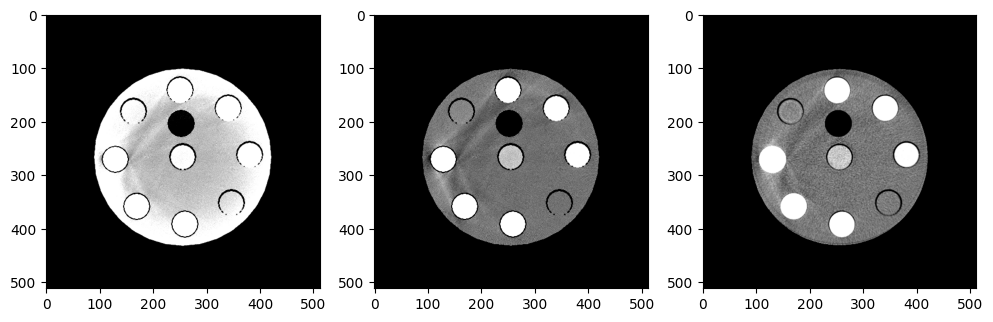

Material, Simul HU, Real HU
water_base, -8.74, -5.84
brain, 18.69, 24.61
adipose, -95.60, -78.38
iodine_10, 297.37, 278.54
true_water, -3.36, 1.82
calcium_300, 963.43, 1021.69
calcium_100, 338.40, 318.72
calcium_50, 176.03, 155.58
water, -12.13, -4.37
iodine_2, 54.92, 54.49
iodine_5, 148.96, 140.50


In [33]:
bhc_water_coeffs_simul = water_bhc_calibration_simul(df_att['true_water'].values, spectrum, mu_waters[ich])
prjs_poly_simul_bhc_water = apply_water_bhc(prjs_poly_simul, bhc_water_coeffs_simul)
# prjs_poly_simul_bhc_water = additional_fbp_filter(prjs_poly_simul_bhc_water)
recon_poly_simul_bhc_water = leapct.FBP(prjs_poly_simul_bhc_water)
recon_poly_simul = leapct.FBP(prjs_poly_simul)

df_hu_simul = get_roi_hu(recon_poly_simul_bhc_water, mask, df_mask, mu_waters[ich])
df_hu_real = get_roi_hu(fbps[ich], mask, df_mask, mu_waters[ich])

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(recon_poly_simul[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.subplot(1, 3, 2)
plt.imshow(recon_poly_simul_bhc_water[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.subplot(1, 3, 3)
plt.imshow(fbps[ich, 0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.show()

print('Material, Simul HU, Real HU')
for i, row in df_hu_simul.iterrows():
    label = row['label']
    material = row['material']
    hu_simul = row['roi_hu']
    hu_real = df_hu_real[df_hu_real['label'] == label]['roi_hu'].values[0]
    print(f'{material}, {hu_simul:.2f}, {hu_real:.2f}')

Material, Simul HU with BHC, Simul HU without BHC, Real HU
water_base, -8.74, -9.02, -5.84
brain, 18.69, 21.57, 24.61
adipose, -95.60, -94.58, -78.38
iodine_10, 297.37, -12.43, 278.54
true_water, -3.36, -7.28, 1.82
calcium_300, 963.43, -14.55, 1021.69
calcium_100, 338.40, -14.77, 318.72
calcium_50, 176.03, -14.49, 155.58
water, -12.13, -12.38, -4.37
iodine_2, 54.92, -12.45, 54.49
iodine_5, 148.96, -12.43, 140.50


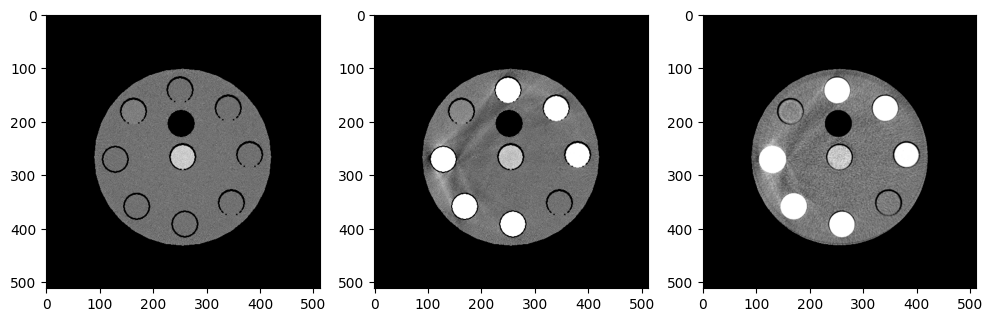

In [34]:
# simulate a BHC free image by replacing every none-water material with water
mus_materials_bhc_free = []
for i in range(len(df_mask)):
    material = df_mask.loc[i, 'Material']
    if any(water_keyword in material.lower() for water_keyword in ['water', 'adipose', 'brain']):
        mus_materials_bhc_free.append(df_att[material].values)
    else:
        mus_materials_bhc_free.append(df_att['water'].values)
mus_materials_bhc_free = np.array(mus_materials_bhc_free)

# compute the polychromatic projection
attenuation = np.sum(prjs_materials[..., None] * mus_materials_bhc_free[:, None, None, None, :], axis=0)
prjs_poly_simul_2 = -np.log(np.sum(spectrum * np.exp(-attenuation), axis=-1)).astype(np.float32)

prjs_poly_simul_2_bhc_water = apply_water_bhc(prjs_poly_simul_2, bhc_water_coeffs_simul)
recon_poly_simul_2_bhc_water = leapct.FBP(prjs_poly_simul_2_bhc_water)

df_hu_simul_2 = get_roi_hu(recon_poly_simul_2_bhc_water, mask, df_mask, mu_waters[ich])
print('Material, Simul HU with BHC, Simul HU without BHC, Real HU')
for i, row in df_hu_simul.iterrows():
    label = row['label']
    material = row['material']
    hu_simul_bhc = row['roi_hu']
    hu_simul_no_bhc = df_hu_simul_2[df_hu_simul_2['label'] == label]['roi_hu'].values[0]
    hu_real = df_hu_real[df_hu_real['label'] == label]['roi_hu'].values[0]
    print(f'{material}, {hu_simul_bhc:.2f}, {hu_simul_no_bhc:.2f}, {hu_real:.2f}')

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(recon_poly_simul_2_bhc_water[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.subplot(1, 3, 2)
plt.imshow(recon_poly_simul_bhc_water[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.subplot(1, 3, 3)
plt.imshow(fbps[ich, 0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.show()

In [35]:
effective_kev = np.exp(np.interp(-np.log(mu_waters[ich]), -np.log(df_att['true_water']), np.log(df_att['energy'])))
effective_mu_calcium_300 = np.exp(np.interp(np.log(effective_kev), np.log(df_att['energy']), np.log(df_att['calcium_300'])))
effective_hu_calcium_300 = (effective_mu_calcium_300 / mu_waters[ich] - 1) * 1000
print('Effective energy:', effective_kev)
print('Effective mu for calcium 300:', effective_mu_calcium_300)
print('Effective HU for calcium 300:', effective_hu_calcium_300)

Effective energy: 67.93825978498282
Effective mu for calcium 300: 0.03818316560201723
Effective HU for calcium 300: 948.1206939804712


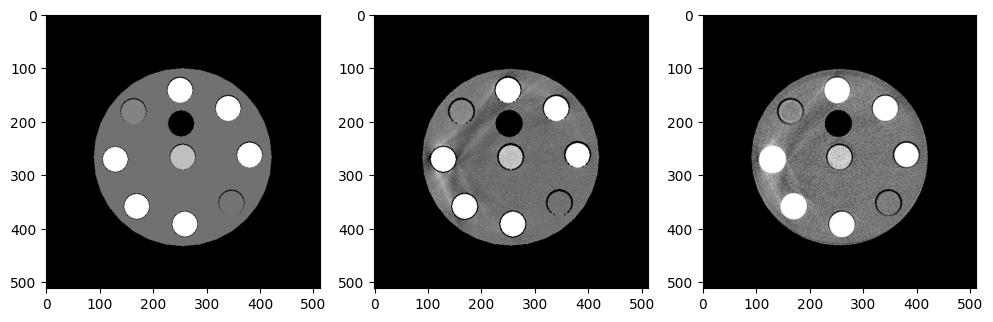

In [36]:
# build a target phantom for ebhc
# use the mean value from df_hu_simul_2 if it is one of water, adipose, or brain
# otherwise use the mean value from df_hu_simul
# convert the hu to mu

target_phantom = np.zeros_like(mask, dtype=np.float32)
for i, row in df_mask.iterrows():
    label = row['Seg']
    material = row['Material']
    hu = df_hu_real[df_hu_real['label'] == label]['roi_hu'].values[0]

    # if any(water_keyword in material.lower() for water_keyword in ['water', 'adipose', 'brain']):
    #     hu = df_hu_simul_2[df_hu_simul_2['label'] == label]['roi_hu'].values[0]
    # # elif material == 'calcium_300':
    # #     hu = effective_hu_calcium_300
    # else:
    #     # hu = df_hu_simul[df_hu_simul['label'] == label]['roi_hu'].values[0]
    #     hu = df_hu_real[df_hu_real['label'] == label]['roi_hu'].values[0]
    mu = (hu + 1000) / 1000 * mu_waters[ich]
    target_phantom[mask == label] = mu

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(target_phantom[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.subplot(1, 3, 2)
plt.imshow(recon_poly_simul_bhc_water[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.subplot(1, 3, 3)
plt.imshow(fbps[ich, 0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.show()

EBHC coefficients: [-0.10270048  0.02349146  0.03225008]


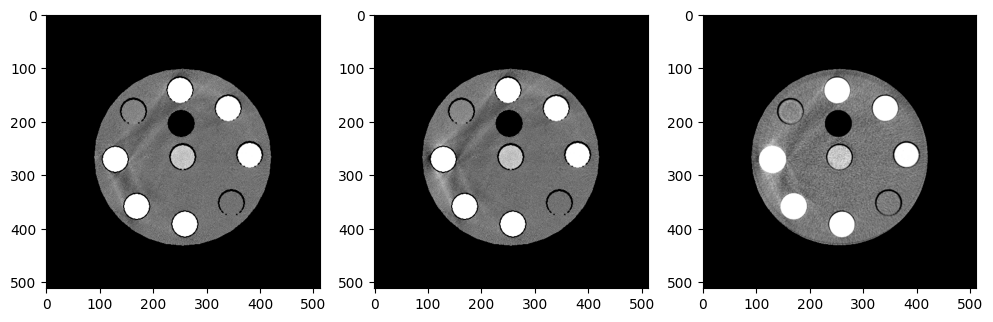

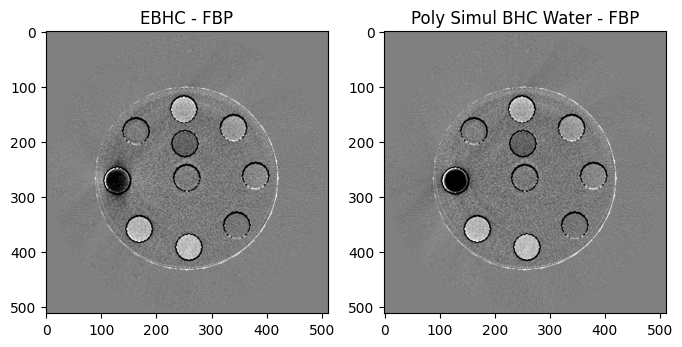

Material, EBHC Simul HU, Real HU
water_base, -8.74, -5.84
brain, 19.69, 24.61
adipose, -95.27, -78.38
iodine_10, 297.96, 278.54
true_water, -4.80, 1.82
calcium_300, 989.09, 1021.69
calcium_100, 338.17, 318.72
calcium_50, 176.31, 155.58
water, -11.92, -4.37
iodine_2, 55.24, 54.49
iodine_5, 149.28, 140.50


In [37]:
# fit the simulated projection to the real data
# first find the high-density components in the reconstruction

threshold = 1700 / 1000 * mu_waters[ich]  # 700 HU in terms of attenuation coefficient
bone_image = np.where(recon_poly_simul_bhc_water > threshold, recon_poly_simul_bhc_water, 0)
prjs_bone = leapct.allocate_projections()
_ = leapct.project(prjs_bone, bone_image)

prjs_real = prjs[ich]
prjs_mask = np.where(prjs_bone > 0)

# fit the bone projection to the projection from the target phantom
prjs_target = leapct.allocate_projections()
_ = leapct.project(prjs_target, target_phantom)

p_t = prjs_target[prjs_mask]
p_b = prjs_bone[prjs_mask]
p_p = prjs_poly_simul_bhc_water[prjs_mask]

A = np.vstack([p_b, p_b * p_p, p_b**2]).T
b = p_t - p_p
coeffs_ebhc = np.linalg.lstsq(A, b, rcond=None)[0]
print('EBHC coefficients:', coeffs_ebhc)

# EBHC
prjs_ebhc = prjs_poly_simul_bhc_water + coeffs_ebhc[0] * prjs_bone + coeffs_ebhc[1] * prjs_bone * prjs_poly_simul_bhc_water + coeffs_ebhc[2] * prjs_bone**2
recon_ebhc = leapct.FBP(prjs_ebhc)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(recon_ebhc[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.subplot(1, 3, 2)
plt.imshow(recon_poly_simul_bhc_water[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.subplot(1, 3, 3)
plt.imshow(fbps[ich, 0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.show()

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(recon_ebhc[0] - fbps[ich, 0], cmap='gray', vmin=-0.001, vmax=0.001)
plt.title('EBHC - FBP')
plt.subplot(1, 2, 2)
plt.imshow(recon_poly_simul_bhc_water[0] - fbps[ich, 0], cmap='gray', vmin=-0.001, vmax=0.001)
plt.title('Poly Simul BHC Water - FBP')
plt.show()

# roi hu
df_hu_ebhc = get_roi_hu(recon_ebhc, mask, df_mask, mu_waters[ich])
print('Material, EBHC Simul HU, Real HU')
for i, row in df_hu_simul.iterrows():
    label = row['label']
    material = row['material']
    hu_ebhc = df_hu_ebhc[df_hu_ebhc['label'] == label]['roi_hu'].values[0]
    hu_real = df_hu_real[df_hu_real['label'] == label]['roi_hu'].values[0]
    print(f'{material}, {hu_ebhc:.2f}, {hu_real:.2f}')

Water BHC coefficients: [9.1219580e-01 9.5262742e-03 6.0808705e-04]
EBHC coefficients: [-0.04445605  0.0137969   0.01687493]


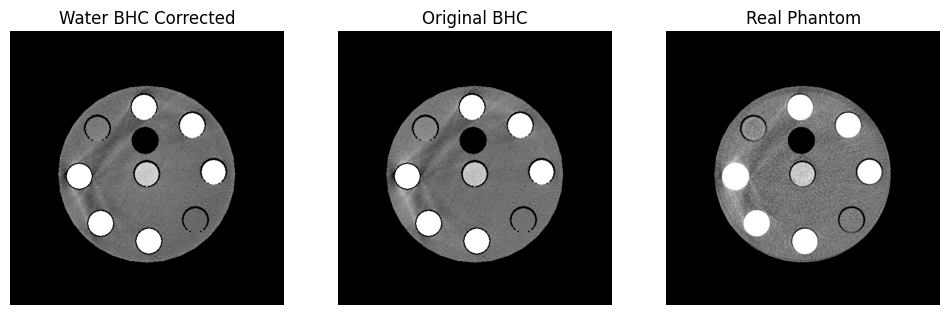

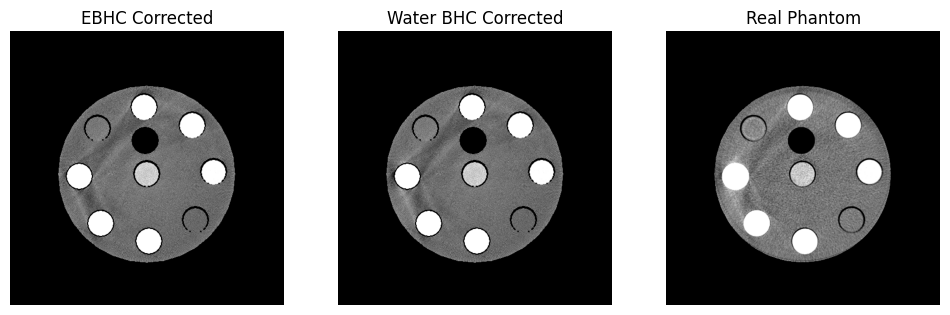

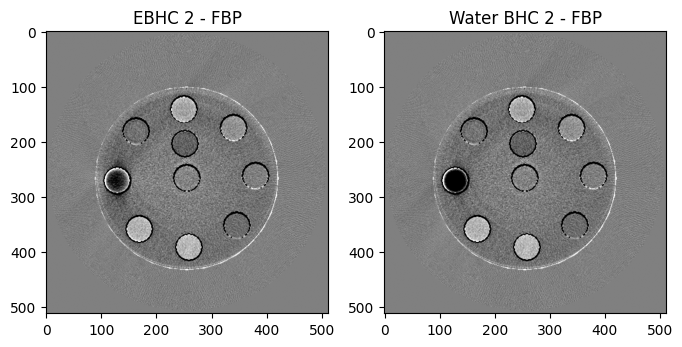

Material, EBHC Simul HU, Real HU
water_base, -10.27, -5.84
brain, 22.79, 24.61
adipose, -95.47, -78.38
iodine_10, 295.92, 278.54
true_water, -8.51, 1.82
calcium_300, 1010.64, 1021.69
calcium_100, 336.61, 318.72
calcium_50, 173.65, 155.58
water, -15.63, -4.37
iodine_2, 51.93, 54.49
iodine_5, 146.44, 140.50


In [ ]:
# water and ebhc calibration using the real phantom image
# first construct ideal phantom using the real phantom.
target_phantom = np.zeros_like(mask, dtype=np.float32)
for i, row in df_mask.iterrows():
    label = row['Seg']
    material = row['Material']
    target_phantom[mask == label] = imgs[ich][mask == label].mean()
prjs_target = leapct.allocate_projections()
_ = leapct.project(prjs_target, target_phantom)

# water correction: avoid calcium_300, everything else uses only the water BHC
prjs_mask_ca300 = np.where(prjs_materials[df_mask['Material'] == 'calcium_300'][0], 1, 0)
prjs_mask = (prjs_mask_ca300 == 0) & (prjs_poly_simul > 0)
input_intensity = prjs_poly_simul[prjs_mask]
target_intensity = prjs_target[prjs_mask]

A = np.vstack([input_intensity**i for i in range(1, 4)]).T
b = target_intensity
coeffs_water_bhc_2 = np.linalg.lstsq(A, b, rcond=None)[0]
print('Water BHC coefficients:', coeffs_water_bhc_2)

prjs_poly_simul_bhc_water_2 = apply_water_bhc(prjs_poly_simul, coeffs_water_bhc_2)
recon_poly_simul_bhc_water_2 = leapct.FBP(prjs_poly_simul_bhc_water_2)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(recon_poly_simul_bhc_water_2[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.title('Water BHC Corrected')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(recon_poly_simul_bhc_water[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.title('Original BHC')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(fbps[ich, 0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.title('Real Phantom')
plt.axis('off')

# EBHC
threshold = 1700 / 1000 * mu_waters[ich]  # 700 HU in terms of attenuation coefficient
bone_image = np.where(recon_poly_simul_bhc_water_2 > threshold, recon_poly_simul_bhc_water_2, 0)
prjs_bone = leapct.allocate_projections()
_ = leapct.project(prjs_bone, bone_image)

prjs_mask = np.where(prjs_bone > 0)
p_t = prjs_target[prjs_mask]
p_b = prjs_bone[prjs_mask]
p_p = prjs_poly_simul_bhc_water_2[prjs_mask]
A = np.vstack([p_b, p_b * p_p, p_b**2]).T
b = p_t - p_p
coeffs_ebhc_2 = np.linalg.lstsq(A, b, rcond=None)[0]
print('EBHC coefficients:', coeffs_ebhc_2)

prjs_ebhc_2 = prjs_poly_simul_bhc_water_2 + coeffs_ebhc_2[0] * prjs_bone + coeffs_ebhc_2[1] * prjs_bone * prjs_poly_simul_bhc_water_2 + coeffs_ebhc_2[2] * prjs_bone**2
recon_ebhc_2 = leapct.FBP(prjs_ebhc_2)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(recon_ebhc_2[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.title('EBHC Corrected')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(recon_poly_simul_bhc_water_2[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.title('Water BHC Corrected')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(fbps[ich, 0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.title('Real Phantom')
plt.axis('off')
plt.show()

# difference image
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(recon_ebhc_2[0] - fbps[ich, 0], cmap='gray', vmin=-0.001, vmax=0.001)
plt.title('EBHC 2 - FBP')
plt.subplot(1, 2, 2)
plt.imshow(recon_poly_simul_bhc_water_2[0] - fbps[ich, 0], cmap='gray', vmin=-0.001, vmax=0.001)
plt.title('Water BHC 2 - FBP')
plt.show()

# get roi value
df_hu_ebhc_2 = get_roi_hu(recon_ebhc_2, mask, df_mask, mu_waters[ich])
print('Material, EBHC Simul HU, Real HU')
for i, row in df_hu_simul.iterrows():
    label = row['label']
    material = row['material']
    hu_ebhc = df_hu_ebhc_2[df_hu_ebhc_2['label'] == label]['roi_hu'].values[0]
    hu_real = df_hu_real[df_hu_real['label'] == label]['roi_hu'].values[0]
    print(f'{material}, {hu_ebhc:.2f}, {hu_real:.2f}')

In [39]:
recon_hu = (recon_ebhc / mu_waters[ich] * 1000 - 1000).astype(np.int16)
sitk_recon = sitk.GetImageFromArray(recon_hu)
sitk_recon.SetSpacing(sitk_mask.GetSpacing())
sitk_recon.SetOrigin(sitk_mask.GetOrigin())
sitk_recon.SetDirection(sitk_mask.GetDirection())
sitk.WriteImage(sitk_recon, os.path.join(calibration_dir, f'recon_ebhc_{ich}.nii.gz'))

recon_hu = (recon_poly_simul_bhc_water / mu_waters[ich] * 1000 - 1000).astype(np.int16)
sitk_recon = sitk.GetImageFromArray(recon_hu)
sitk_recon.SetSpacing(sitk_mask.GetSpacing())
sitk_recon.SetOrigin(sitk_mask.GetOrigin())
sitk_recon.SetDirection(sitk_mask.GetDirection())
sitk.WriteImage(sitk_recon, os.path.join(calibration_dir, f'recon_bhc_water_{ich}.nii.gz'))

In [40]:
# calculate the attenuation coefficient of each material and see their equivalent single energy
def get_mono_energy(hu_val, mu_water, df_att):
    mu_val = (hu_val + 1000) / 1000 * mu_water
    energy = np.exp(np.interp(-np.log(mu_val), -np.log(df_att['true_water']), np.log(df_att['energy'])))
    return energy

for i, row in df_hu_real.iterrows():
    label = row['label']
    material = row['material']
    hu_real = row['roi_hu']
    mono_energy = get_mono_energy(hu_real, mu_waters[ich], df_att)
    print(f'{material}, {hu_real:.2f}, {mono_energy:.2f} keV')

water_base, -5.84, 68.95 keV
brain, 24.61, 63.90 keV
adipose, -78.38, 84.20 keV
iodine_10, 278.54, 43.81 keV
true_water, 1.82, 67.63 keV
calcium_300, 1021.69, 29.16 keV
calcium_100, 318.72, 42.04 keV
calcium_50, 155.58, 50.17 keV
water, -4.37, 68.69 keV
iodine_2, 54.49, 59.58 keV
iodine_5, 140.50, 51.42 keV


In [41]:
for i, row in df_hu_ebhc.iterrows():
    label = row['label']
    material = row['material']
    hu_real = row['roi_hu']
    mono_energy = get_mono_energy(hu_real, mu_waters[ich], df_att)
    print(f'{material}, {hu_real:.2f}, {mono_energy:.2f} keV')

water_base, -8.74, 69.46 keV
brain, 19.69, 64.68 keV
adipose, -95.27, 89.07 keV
iodine_10, 297.96, 42.94 keV
true_water, -4.80, 68.77 keV
calcium_300, 989.09, 29.42 keV
calcium_100, 338.17, 41.23 keV
calcium_50, 176.31, 48.95 keV
water, -11.92, 70.02 keV
iodine_2, 55.24, 59.50 keV
iodine_5, 149.28, 50.69 keV
